# LSTM Model Creation
This nb creates the LSTM model uesd in the CRZ dashboard

## Load in data

In [32]:
import pandas as pd
import numpy as np
import datetime as dt

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
data = pd.read_csv('../data/processed_data.csv',index_col=None)

## Split data

In [3]:
# 70-15-15 train-val-test split
timestamps = data["toll_10_minute_block"].sort_values().unique()

train_cutoff = timestamps[int(len(timestamps) * 0.70)]
val_cutoff   = timestamps[int(len(timestamps) * 0.85)]

train = data[
    data["toll_10_minute_block"] < train_cutoff
].copy()

val = data[
    (data["toll_10_minute_block"] >= train_cutoff) &
    (data["toll_10_minute_block"] < val_cutoff)
].copy()

test = data[
    data["toll_10_minute_block"] >= val_cutoff
].copy()

In [4]:
# confirm ranges
print(
    f"""Train:
    \n{train['toll_10_minute_block'].min()}
    \nto {train['toll_10_minute_block'].max()}
    \nTotal records: {len(train):,}, {len(train)/len(data):.2%} of total data"""
)

print("\n------------------------------------------------------------\n")

print(
    f"""Validation:
    \n{val['toll_10_minute_block'].min()}
    \nto {val['toll_10_minute_block'].max()}
    \nTotal records: {len(val):,}, {len(val)/len(data):.2%} of total data"""
)

print("\n------------------------------------------------------------\n")

print(
    f"""*Test*:
    \n{test['toll_10_minute_block'].min()}
    \nto {test['toll_10_minute_block'].max()}
    \nTotal records: {len(test):,}, {len(test)/len(data):.2%} of total data"""
)

Train:
    
2025-01-05 00:00:00
    
to 2026-02-25 11:40:00
    
Total records: 719,700, 70.00% of total data

------------------------------------------------------------

Validation:
    
2026-02-25 11:50:00
    
to 2026-05-25 17:50:00
    
Total records: 154,236, 15.00% of total data

------------------------------------------------------------

*Test*:
    
2026-05-25 18:00:00
    
to 2026-08-22 23:50:00
    
Total records: 154,224, 15.00% of total data


## Feature Engineering

In [5]:
# scaling y-target
traffic_scaler = StandardScaler()

# fit to training data
train["traffic_scaled"] = traffic_scaler.fit_transform(
    train[["traffic_volume"]]
)

# transform val/test data based on fitted scaler
val["traffic_scaled"] = traffic_scaler.transform(
    val[["traffic_volume"]]
)

test["traffic_scaled"] = traffic_scaler.transform(
    test[["traffic_volume"]]
)

In [6]:
# select features for modeling
numeric_features = [
    "traffic_scaled",
    "holiday_ind",
    "overnight_ind",
    "dow_sin",
    "dow_cos"
]

categorical_features = [
    "region_id",
    "group_id"
]

# 10 minute steps for a 24h day
SEQ_LENGTH = 144

### Batch windows

In [ ]:
def make_group_dataset(group_df, numeric_features, seq_length=144):

    group_df = (
        group_df
        .sort_values("toll_10_minute_block")
        .reset_index(drop=True)
    )

    # Convert Pandas columns to compact NumPy arrays once
    numeric = group_df[numeric_features].to_numpy(dtype=np.float32)

    region = group_df["region_id"].to_numpy(dtype=np.int32)

    group = group_df["group_id"].to_numpy(dtype=np.int32)

    target = group_df["traffic_scaled"].to_numpy(dtype=np.float32)


    # Previous 144 rows of numeric features
    numeric_ds = tf.keras.utils.timeseries_dataset_from_array(
        data=numeric[:-1],
        targets=None,
        sequence_length=seq_length,
        sequence_stride=1,
        shuffle=False,
        batch_size=None
    )


    # Previous 144 region IDs
    region_ds = tf.keras.utils.timeseries_dataset_from_array(
        data=region[:-1],
        targets=None,
        sequence_length=seq_length,
        sequence_stride=1,
        shuffle=False,
        batch_size=None
    )


    # Previous 144 group IDs
    group_ds = tf.keras.utils.timeseries_dataset_from_array(
        data=group[:-1],
        targets=None,
        sequence_length=seq_length,
        sequence_stride=1,
        shuffle=False,
        batch_size=None
    )


    # Target is the NEXT traffic value
    target_ds = tf.data.Dataset.from_tensor_slices(
        target[seq_length:]
    )


    # Combine everything
    ds = tf.data.Dataset.zip(
        (
            numeric_ds,
            region_ds,
            group_ds,
            target_ds
        )
    )

    return ds

In [8]:
train_ds = None

for group_id, group_df in train.groupby("group_id"):

    group_ds = make_group_dataset(
        group_df,
        numeric_features,
        SEQ_LENGTH
    )

    if train_ds is None:
        train_ds = group_ds
    else:
        train_ds = train_ds.concatenate(group_ds)

In [9]:
BATCH_SIZE = 256

train_ds = (
    train_ds
    .shuffle(20_000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [10]:
batch = next(iter(train_ds))

numeric_batch, region_batch, group_batch, y_batch = batch

print("numeric:", numeric_batch.shape)
print("region:", region_batch.shape)
print("group:", group_batch.shape)
print("target:", y_batch.shape)

numeric: (256, 144, 5)
region: (256, 144)
group: (256, 144)
target: (256,)


### Tensorflow model inputs

In [11]:


numeric_input = layers.Input(
    shape=(SEQ_LENGTH, len(numeric_features)),
    name="numeric"
)

region_input = layers.Input(
    shape=(SEQ_LENGTH,),
    dtype="int32",
    name="region"
)

group_input = layers.Input(
    shape=(SEQ_LENGTH,),
    dtype="int32",
    name="group"
)

In [12]:
# embedding layers for categorical features
n_regions = int(data["region_id"].max()) + 1
n_groups = int(data["group_id"].max()) + 1

In [13]:
region_embedding = layers.Embedding(
    input_dim=n_regions,
    output_dim=3,
    name="region_embedding"
)(region_input)

group_embedding = layers.Embedding(
    input_dim=n_groups,
    output_dim=4,
    name="group_embedding"
)(group_input)

In [14]:
print("Region embedding shape:", region_embedding.shape)
print("Group embedding shape:", group_embedding.shape)

Region embedding shape: (None, 144, 3)
Group embedding shape: (None, 144, 4)


In [15]:
x = layers.Concatenate(axis=-1)([
    numeric_input,
    region_embedding,
    group_embedding
])

In [16]:
x.shape

(None, 144, 12)

## LSTM Layers

In [17]:
x = layers.LSTM(
    64,
    name="lstm"
)(x)

x.shape

(None, 64)

In [18]:
output = layers.Dense(
    1,
    name="traffic_prediction"
)(x)

### LSTM Modeling

In [19]:
model = Model(
    inputs={
        "numeric": numeric_input,
        "region": region_input,
        "group": group_input
    },
    outputs=output
)

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ region (InputLayer) │ (None, 144)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group (InputLayer)  │ (None, 144)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 144, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region_embedding    │ (None, 144, 3)    │         24 │ region[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_embedding     │ (None, 144, 4)    │         52 │ group[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144, 12)   │          0 │ numeric[0][0],    │
│ (Concatenate)       │                   │            │ region_embedding… │
│                     │                   │            │ group_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,712 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ traffic_prediction  │ (None, 1)         │         65 │ lstm[0][0]        │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,853 (77.55 KB)

 Trainable params: 19,853 (77.55 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

### Validate model

In [22]:
val_ds = None

for group_id, group_df in val.groupby("group_id"):

    group_ds = make_group_dataset(
        group_df,
        numeric_features,
        SEQ_LENGTH
    )

    if val_ds is None:
        val_ds = group_ds
    else:
        val_ds = val_ds.concatenate(group_ds)

In [23]:
val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [24]:
batch = next(iter(val_ds))

numeric_batch, region_batch, group_batch, y_batch = batch

print("numeric:", numeric_batch.shape)
print("region:", region_batch.shape)
print("group:", group_batch.shape)
print("target:", y_batch.shape)

numeric: (256, 144, 5)
region: (256, 144)
group: (256, 144)
target: (256,)


In [26]:
def format_for_model(numeric, region, group, target):
    return {
        "numeric": numeric,
        "region": region,
        "group": group
    }, target

In [27]:
train_ds = train_ds.map(
    format_for_model,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    format_for_model,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [28]:
x_batch, y_batch = next(iter(train_ds))

print(x_batch["numeric"].shape)
print(x_batch["region"].shape)
print(x_batch["group"].shape)
print(y_batch.shape)

(256, 144, 5)
(256, 144)
(256, 144)
(256,)


## Fit model

In [ ]:
# recompile model
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [33]:
# define early stopping params
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [36]:
# define model checkpoint
checkpoint = ModelCheckpoint(
    filepath="../models/checkpoints/epoch_{epoch:02d}.keras",
    save_weights_only=False,
    save_freq="epoch"
)

In [38]:
# define best validation checkpoint
best_checkpoint = ModelCheckpoint(
    filepath="../models/checkpoints/epoch_{epoch:02d}.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False
)

In [39]:
# return Keras History object with training metrics
# add early stopping, best_checkpoint for best validation loss and checkpoint for saving all epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        checkpoint,
        best_checkpoint,
        early_stopping
    ]
)

Epoch 1/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 291s 104ms/step - loss: 0.0301 - mae: 0.1223 - val_loss: 0.0389 - val_mae: 0.1401
Epoch 2/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 276s 98ms/step - loss: 0.0295 - mae: 0.1212 - val_loss: 0.0387 - val_mae: 0.1392
Epoch 3/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 281s 100ms/step - loss: 0.0291 - mae: 0.1205 - val_loss: 0.0366 - val_mae: 0.1356
Epoch 4/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 285s 102ms/step - loss: 0.0286 - mae: 0.1191 - val_loss: 0.0370 - val_mae: 0.1354
Epoch 5/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 296s 105ms/step - loss: 0.0283 - mae: 0.1184 - val_loss: 0.0353 - val_mae: 0.1326
Epoch 6/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 294s 105ms/step - loss: 0.0280 - mae: 0.1178 - val_loss: 0.0342 - val_mae: 0.1313
Epoch 7/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 288s 102ms/step - loss: 0.0278 - mae: 0.1172 - val_loss: 0.0341 - val_mae: 0.1307
Epoch 8/50
2805/2805 ━━━━━━━━━━━━━━━━━━━━ 284s 101ms/step - loss: 0.0276 - mae: 0.1168 - val_loss: 0.0321 - val_mae: 0.1259
Epoch 9/5

## Reviewing Loss

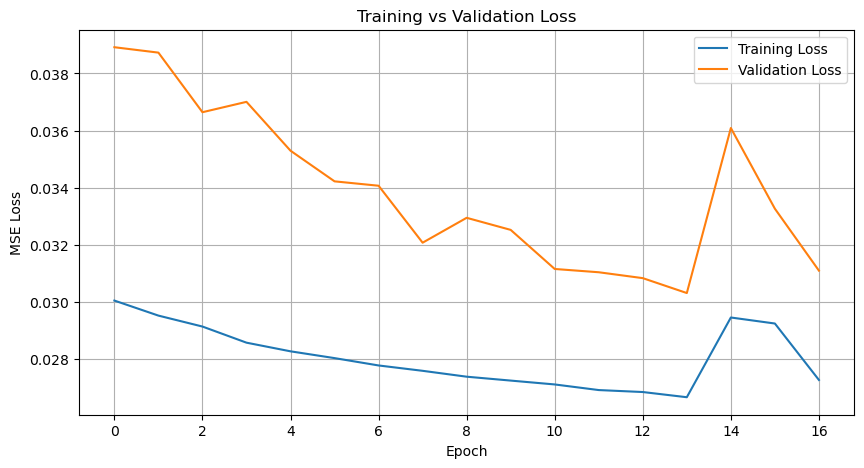

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Testing Model

In [41]:
test_ds = None

for group_id, test_group in test.groupby("group_id"):

    # Last 144 observations before the test period
    history = (
        val[val["group_id"] == group_id]
        .sort_values("toll_10_minute_block")
        .tail(SEQ_LENGTH)
    )

    # Safety check
    if len(history) < SEQ_LENGTH:
        raise ValueError(
            f"group_id {group_id} has only {len(history)} "
            f"history rows; need {SEQ_LENGTH}"
        )

    # History + actual test period
    combined = pd.concat(
        [history, test_group],
        ignore_index=True
    )

    group_ds = make_group_dataset(
        combined,
        numeric_features,
        SEQ_LENGTH
    )

    if test_ds is None:
        test_ds = group_ds
    else:
        test_ds = test_ds.concatenate(group_ds)

In [42]:
test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .map(
        format_for_model,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)

In [43]:
x_batch, y_batch = next(iter(test_ds))

print(x_batch["numeric"].shape)
print(x_batch["region"].shape)
print(x_batch["group"].shape)
print(y_batch.shape)

(256, 144, 5)
(256, 144)
(256, 144)
(256,)


In [44]:
test_loss, test_mae = model.evaluate(test_ds)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - loss: 0.0294 - mae: 0.1215
Test MSE: 0.02936439774930477
Test MAE: 0.12150625884532928


In [45]:
pred_scaled = model.predict(test_ds)

y_test_scaled = np.concatenate([
    y.numpy()
    for x, y in test_ds
])

603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step


In [46]:
pred_actual = traffic_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

y_test_actual = traffic_scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
).flatten()

In [47]:
from sklearn.metrics import mean_absolute_error

mae_actual = mean_absolute_error(
    y_test_actual,
    pred_actual
)

print("Test MAE in traffic volume:", mae_actual)

Test MAE in traffic volume: 22.061809539794922


## Pred v Actual

In [48]:
prediction_rows = []

for group_id, test_group in test.groupby("group_id"):

    test_group = (
        test_group
        .sort_values("toll_10_minute_block")
        .reset_index(drop=True)
    )

    prediction_rows.append(
        test_group[
            [
                "toll_10_minute_block",
                "region_id",
                "group_id"
            ]
        ]
    )

results = pd.concat(
    prediction_rows,
    ignore_index=True
)

In [49]:
results["actual_traffic"] = y_test_actual
results["predicted_traffic"] = pred_actual

In [50]:
print(results.shape)
print(len(pred_actual))

results.head()

(154224, 5)
154224


,toll_10_minute_block,region_id,group_id,actual_traffic,predicted_traffic
0,2026-05-25 18:00:00,1,1,328.0,341.663818
1,2026-05-25 18:10:00,1,1,369.0,334.892914
2,2026-05-25 18:20:00,1,1,365.0,349.200409
3,2026-05-25 18:30:00,1,1,329.0,352.816681
4,2026-05-25 18:40:00,1,1,331.0,342.455505


In [51]:
group_to_plot = 1

plot_data = results[
    results["group_id"] == group_to_plot
].copy()

In [52]:
plot_data = plot_data.head(7 * 144)

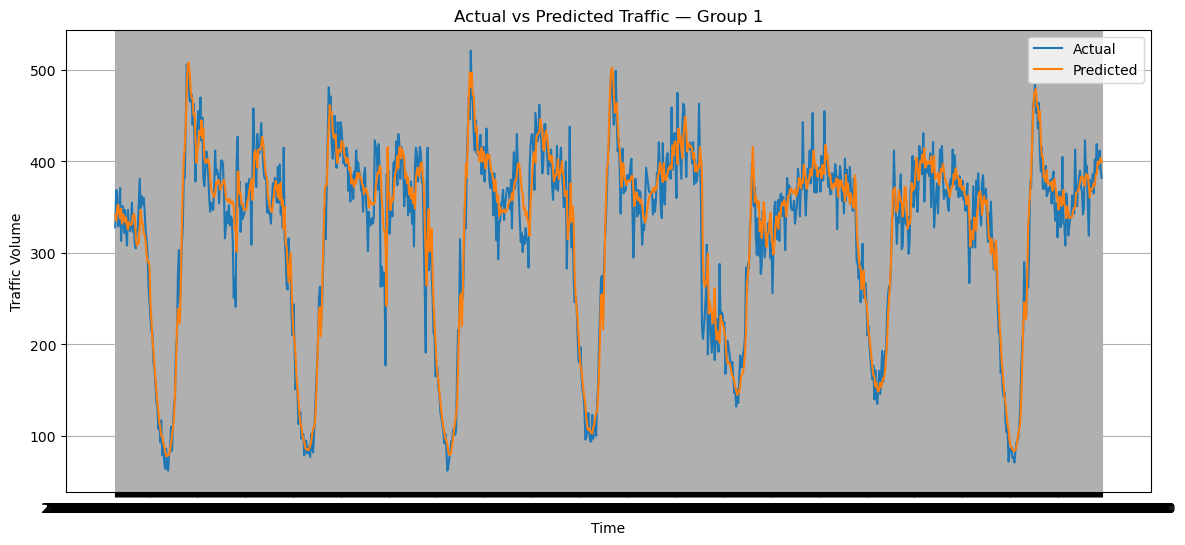

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["toll_10_minute_block"],
    plot_data["actual_traffic"],
    label="Actual"
)

plt.plot(
    plot_data["toll_10_minute_block"],
    plot_data["predicted_traffic"],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.title(f"Actual vs Predicted Traffic — Group {group_to_plot}")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
# performance by group
group_performance = (
    results
    .assign(
        absolute_error=lambda x:
            abs(x["actual_traffic"] - x["predicted_traffic"])
    )
    .groupby("group_id")
    .agg(
        mae=("absolute_error", "mean"),
        mean_traffic=("actual_traffic", "mean")
    )
)

group_performance["mae_pct_of_mean"] = (
    group_performance["mae"]
    / group_performance["mean_traffic"]
    * 100
)

group_performance

,mae,mean_traffic,mae_pct_of_mean
group_id,,,
1,22.679508,320.974335,7.065833
2,19.220234,214.979843,8.940482
3,19.154659,277.868805,6.893419
4,18.742231,195.751480,9.574503
5,19.030428,245.981644,7.736524
6,21.395676,306.188934,6.987736
7,20.995283,298.246735,7.039568
8,23.272627,288.025604,8.080055
9,23.458065,335.230927,6.997584


## Compare LSTM to baseline

In [57]:
traffic_lookup = data[
    [
        "toll_10_minute_block",
        "group_id",
        "traffic_volume"
    ]
].rename(
    columns={
        "toll_10_minute_block": "previous_day_time",
        "traffic_volume": "baseline_prediction"
    }
)

In [66]:
# Make sure timestamps are datetimes
data["toll_10_minute_block"] = pd.to_datetime(
    data["toll_10_minute_block"]
)

test["toll_10_minute_block"] = pd.to_datetime(
    test["toll_10_minute_block"]
)

# Start with the test rows
baseline = test[
    [
        "toll_10_minute_block",
        "group_id",
        "traffic_volume"
    ]
].copy()

# Timestamp from exactly 24 hours earlier
baseline["previous_day_time"] = (
    baseline["toll_10_minute_block"]
    - pd.Timedelta(days=1)
)

# Lookup table from the full dataset
traffic_lookup = data[
    [
        "toll_10_minute_block",
        "group_id",
        "traffic_volume"
    ]
].copy()

traffic_lookup = traffic_lookup.rename(
    columns={
        "toll_10_minute_block": "previous_day_time",
        "traffic_volume": "baseline_prediction"
    }
)

# Attach yesterday's traffic as the prediction
baseline = baseline.merge(
    traffic_lookup,
    on=["group_id", "previous_day_time"],
    how="left"
)

In [69]:
print(baseline["baseline_prediction"].isna().sum())

0


In [71]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    baseline["traffic_volume"],
    baseline["baseline_prediction"]
)

print("Yesterday baseline MAE:", baseline_mae)
print("LSTM MAE:", mae_actual)

Yesterday baseline MAE: 52.5947323373794
LSTM MAE: 22.061809539794922


## Saving model

In [72]:
model.save("../models/lstm_traffic_model.keras")

In [ ]:
import joblib

joblib.dump(
    traffic_scaler,
    "../models/traffic_scaler.joblib"
)

['traffic_scaler.joblib']

In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model("traffic_lstm.keras")

# import joblib

# traffic_scaler = joblib.load(
#     "traffic_scaler.joblib"
# )